## A. О параметрах

Пусть задана нейронная сеть на torch:

```python
model = nn.Sequential(
          nn.Linear(128,64),
          nn.ReLU(),
          nn.Linear(64,8),
          nn.ReLU()
        )
```

Посчитайте количество обучаемых параметров в этой сети. В ответе укажите целое число.

In [1]:
(128 + 1) * 64 + (64 + 1) * 8 # Не забываем про bias

8776

## B. Dropout

На лекции мы обсуждали, что использование Dropout можно рассматривать как параллельное обучение нескольких сетей меньшего размера. Пусть есть нейронная сеть, заданная как

```python
model = nn.Sequential(
          nn.Linear(32, 16),
          Dropout(fraction=0.5),
          nn.ReLU(),
          nn.Linear(16, 8),
          Dropout(fraction=0.6),
          nn.ReLU()
          nn.Linear(8, 8),
          Dropout(fraction=0.5),
          nn.ReLU()
          nn.Linear(8, 3),
          nn.SoftMax()
        )
```

Сколько максимум различных сетей меньшего размера может получиться в данном случае, если слой Dropout зануляет ровно fraction нейронов (округление математическое)?


In [2]:
from math import factorial as f

def C(n: int, k: int) -> int:
  return f(n) // (f(k) * f(n - k))

C(16, int(16 * 0.5)) * C(8, int(8 * 0.4)) * C(8, int(8 * 0.5))

50450400

## C. Загадочная нейросеть

Эта нейронная сеть 10 раз посмотрела один сериал, но запомнила только ЭТО. Что?

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 10),
            nn.ReLU(),
            nn.Linear(10, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 1340),
            nn.Sigmoid()
        )
    def forward(self, x):
        output = self.layers(x)
        return output
    
    def predict_img(self, x):
        output = self.layers(x)
        output = output.reshape(20, 67)
        return output.detach().numpy()

In [5]:
model = Network()
model.load_state_dict(torch.load('misterious_model.pth', map_location=torch.device('cpu')))
model.eval()

Network(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=1340, bias=True)
    (7): Sigmoid()
  )
)

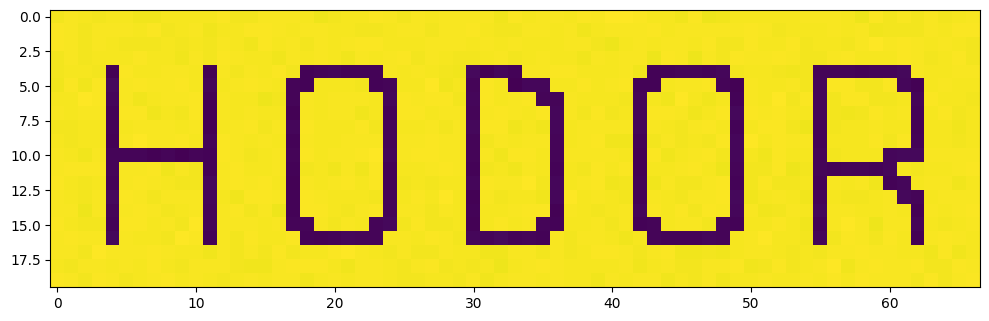

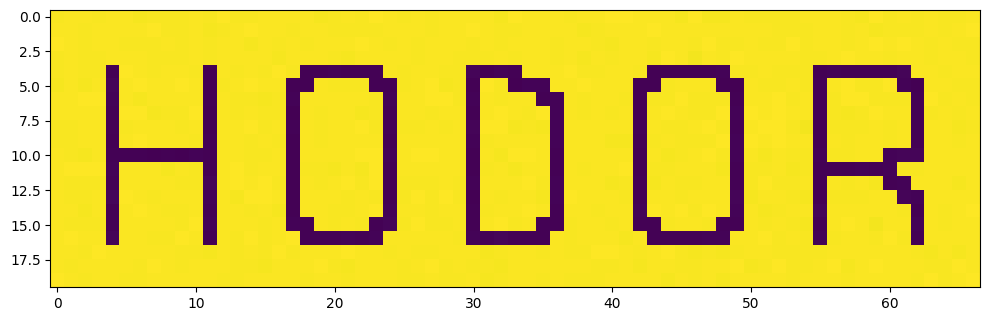

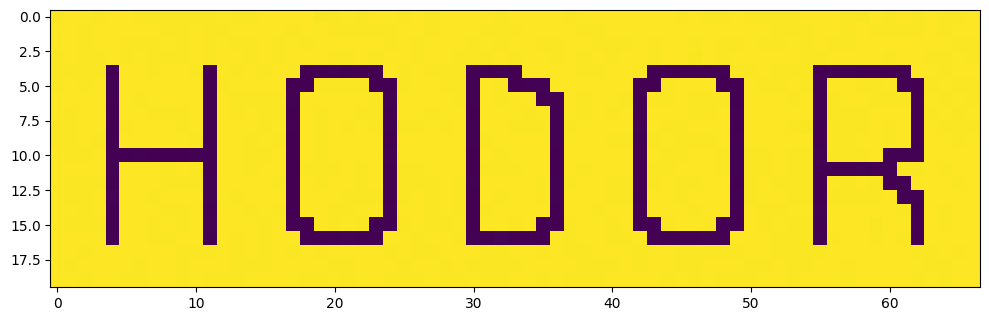

In [6]:
def predict_and_visualize(x_value):
    input_tensor = torch.tensor([[x_value]], dtype=torch.float32)
    
    with torch.no_grad():
        image_array = model.predict_img(input_tensor)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(image_array)    
    plt.tight_layout()
    plt.show()
    
    return image_array

img1 = predict_and_visualize(0.0)

img2 = predict_and_visualize(0.5)

img3 = predict_and_visualize(1.0)